# Optimum Integral Design Upgrade Testing Notes:

In [1]:
# TALK TO RAMESH ABOUT GETTING SOURCE CODE

# There is a Python MINUIT port

# Library Importation:
import numpy as np
from iminuit import Minuit
from iminuit.cost import UnbinnedNLL
from scipy.stats import norm
import panel as pn
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

## 1. Reading in Input Files

### 1.1 X01 Input File:

In [2]:
# Config reader function
def config_reader(filename):
    # Define variables
    sections = {}
    current_section = None
    
    # Creates a dictionary for each section
    with open(filename, 'r') as file:
        for i, line in enumerate(file):
            # Ignores comments that start with a #
            if line.startswith('#'):
                continue
            line = line.strip()
            # Defines sections as those that start with a ##
            if line.startswith('$'):
                # Creates a new section title:
                current_section = line[1:].strip()
                sections[current_section] = []
            elif current_section is not None:
                # Adds the line to the section if appropriate
                sections[current_section].append(line)
            else:
                # Blank lines are just ignored
                continue
    return sections

In [3]:
#print(sections)
config = config_reader('X01_eic-pbl-v7h.txt')
print(config["Settings"][0])

VC2CB=True


In [4]:
# Need to specify spacing of actual blocks and make sure all config info is taken care of
# Go based on what the Fortran config says to do
# Need to add in physical units too

# Once I am able to plot for a given block configuration, then we can optimize the field produced with MINUIT

# Once this is done, we can then move on to making a nice interface for the program

## Config File Definitions:

### Settings
* VC2CB=True -> Flag to allow variable conductor spacing in body
* VC2CE=True -> Flag to allow variable conductor spacing in ends
* MAGTYPE=2 -> 2 for Dipole; 4 for quadrupole; 3 for combine function
* LAYERS=2 -> Total Number of Layers
* RFEMM=110 -> Iron Inner Radius in mm; If zero, No Iron
* R0MM=40 -> Reference Radius in mm
* RBENDMM=10 -> Bend Radius at Transition to End Sector
* NBEND=10 -> Number of Points on Bend Curve

### Layer Descriptions
* 1 -> Number of Blocks in Layer Straight Section = 3
* 2 -> Number of Blocks in Layer End Section = 3
* 3 -> Straight Section Length (m) = 0.6
* 4 -> Wire Diameter (mm) = 1.1
* 5 -> Layer Coil Radius (mm) = 57
* 6 -> Wire Current (A) = 800
* 7 -> Wire Insulation in End Section (mm) = 0.4
* 8 -> Wire Insulation in Straight Section (mm) = 0.20

3 3 0.6 1.1 57. 800 0.4 0.20
3 3 0.6 1.1 58.5 800 0.4 0.20

(Only worried about straight sections for 2D cross section right now)

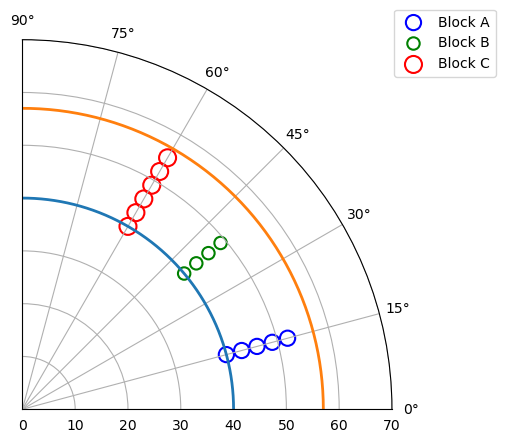

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Set up figure and polar axis
fig, ax = plt.subplots(subplot_kw={'polar': True})

def plot_conductor_block(num_conductors, spacing, phi, radius=2, marker_size=100, color='blue', label_prefix='Block'):
    """
    Plots a block of conductors stacked radially (same theta) as hollow circles.

    Args:
        num_conductors (int): Number of conductors in the block.
        spacing (float): Radial spacing between conductors.
        phi (float): Fixed angle (degrees) where the block is placed.
        radius (float): Starting radius for the first conductor.
        marker_size (float): Marker size.
        color (str): Circle edge color.
        label_prefix (str): Label prefix for legend.
    """
    theta_rad = np.deg2rad(phi)  # fixed angle
    thetas = np.full(num_conductors, theta_rad)
    r = radius + np.arange(num_conductors) * spacing  # increasing radius

    ax.scatter(
        thetas,
        r,
        facecolors='none',
        edgecolors=color,
        s=marker_size,
        linewidth=1.5,
        label=f'{label_prefix}'
    )


theta = np.linspace(0, np.pi, 300)
ax.plot(theta, np.full_like(theta, 40), linewidth=2)
ax.plot(theta, np.full_like(theta, 57), linewidth=2)

# Plotting radially stacked blocks (on fixed angle)
plot_conductor_block(num_conductors=5, spacing=3, phi=15, radius=40, marker_size=120, color='blue', label_prefix='Block A')
plot_conductor_block(num_conductors=4, spacing=3, phi=40, radius=40, marker_size=80, color='green', label_prefix='Block B')
plot_conductor_block(num_conductors=6, spacing=3, phi=60, radius=40, marker_size=150, color='red', label_prefix='Block C')


# Show full first quadrant
ax.set_thetamin(0)
ax.set_thetamax(90)
ax.set_rlim(0, 70)

# Ticks and grid
ax.set_xticks(np.deg2rad(np.arange(0, 91, 15)))
ax.grid(True)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

#plt.title("Conductor Blocks with Specified Spacing, Count, and Size")
plt.show()

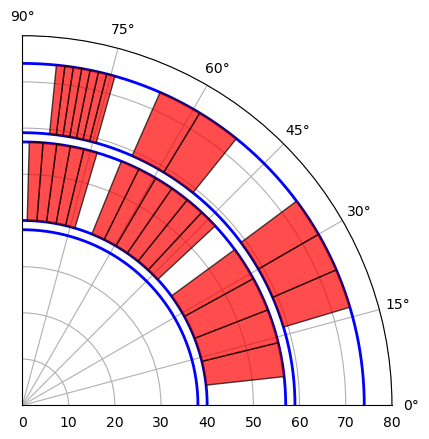

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Needs to account for multiple layers and to iterate plots with this in mind

fig, ax = plt.subplots(subplot_kw={'polar': True})

def plot_conductor_sectors(num_blocks, r_start, r_end, theta_start_deg, theta_end_deg, color='blue', label_prefix='Block'):
    """
    Args:
        num_blocks (int): number of wedges subdividing the sector angularly
        r_start (float): starting radius of wedges
        r_end (float): ending radius of wedges
        theta_start_deg (float): start angle of sector in degrees
        theta_end_deg (float): end angle of sector in degrees
        color (str): wedge color
    """
    total_theta = theta_end_deg - theta_start_deg # Total delta theta
    wedge_width_deg = total_theta / num_blocks # The angular width of each individual wedge in a sector
    radial_height = r_end - r_start # The radial height of the sectors

    # This loop plots each of the wedges in each sector
    for i in range(num_blocks):
        theta = np.deg2rad(theta_start_deg + i * wedge_width_deg)
        width = np.deg2rad(wedge_width_deg)

        ax.bar(theta,
               height=radial_height,
               width=width,
               bottom=r_start,
               color=color,
               edgecolor='black',
               alpha=0.7,
               label=label_prefix if i == 0 else None,
               zorder=3
              )

# Boundary arcs for reference
theta = np.linspace(0, np.pi/2, 300) # Allows theta to go around the entire circle

# Plots of the circles that contain the sectors

# The layers in terms of concentric circles
R0 = 38
layer1_inrad = 40
spacing1 = layer1_inrad - R0
layer1_outrad = 57
layer2_inrad = 59
spacing2 = layer2_inrad - layer1_outrad
layer2_outrad = 74


# Inner circle 
ax.plot(theta, np.full_like(theta, 38), linewidth=2, color='blue')

# Layer 1 ring
ax.plot(theta, np.full_like(theta, 40), linewidth=2, color='blue')
ax.plot(theta, np.full_like(theta, 57), linewidth=2, color='blue')

# Layer 2 ring
ax.plot(theta, np.full_like(theta, 59), linewidth=2, color='blue')
ax.plot(theta, np.full_like(theta, 74), linewidth=2, color='blue')

# Plot blocks subdividing angular sectors with radial extension

# Layer 1:
plot_conductor_sectors(num_blocks=4, r_start=40, r_end=57,
                            theta_start_deg=10, theta_end_deg=40,
                            color='red', label_prefix='Block A')

plot_conductor_sectors(num_blocks=6, r_start=40, r_end=57,
                            theta_start_deg=45, theta_end_deg=70,
                            color='red', label_prefix='Block B')

plot_conductor_sectors(num_blocks=5, r_start=40, r_end=57,
                            theta_start_deg=75, theta_end_deg=90,
                            color='red', label_prefix='Block C')

# Layer 2:
plot_conductor_sectors(num_blocks=3, r_start=59, r_end=74,
                            theta_start_deg=20, theta_end_deg=40,
                            color='red', label_prefix='Block D')

plot_conductor_sectors(num_blocks=2, r_start=59, r_end=74,
                            theta_start_deg=55, theta_end_deg=70,
                            color='red', label_prefix='Block E')

plot_conductor_sectors(num_blocks=7, r_start=59, r_end=74,
                            theta_start_deg=75, theta_end_deg=85,
                            color='red', label_prefix='Block F')


# Polar plot settings
ax.set_thetamin(0)
ax.set_thetamax(90)
ax.set_rlim(0, 80)
ax.set_xticks(np.deg2rad(np.arange(0, 91, 15)))
#ax.grid(True)
#ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.show()


For boundary conditons, we can apply Neumann and Dirchlett boundary conditions to account for the 1/4 of a circle present

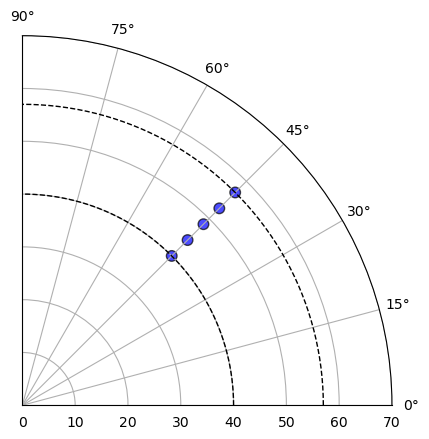

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Set up polar plot
fig, ax = plt.subplots(subplot_kw={'polar': True})
ax.set_aspect('equal')  # Keep circles undistorted

# Parameters
theta_deg = 45                 # Fixed theta angle in degrees
theta_rad = np.deg2rad(theta_deg)
r_start = 40                   # Inner radius
r_end = 57                     # Outer radius
num_circles = 5
circle_radius = 1.0           # Radius of each plotted circle
color = 'blue'

# Compute evenly spaced radial positions between r_start and r_end
r_values = np.linspace(r_start, r_end, num_circles)

# Plot circles
for r in r_values:
    # Convert polar to Cartesian coordinates
    x = r * np.cos(theta_rad)
    y = r * np.sin(theta_rad)

    circle = patches.Circle((x, y),
                            radius=circle_radius,
                            facecolor=color,
                            edgecolor='black',
                            alpha=0.7)
    ax.add_patch(circle)
    # Transform to match polar plot space
    circle.set_transform(ax.transData._b)

# Add reference circles (optional)
theta = np.linspace(0, np.pi, 300)
ax.plot(theta, np.full_like(theta, r_start), 'k--', lw=1)
ax.plot(theta, np.full_like(theta, r_end), 'k--', lw=1)

# Polar plot settings
ax.set_thetamin(0)
ax.set_thetamax(90)
ax.set_rlim(0, 70)
ax.set_xticks(np.deg2rad(np.arange(0, 91, 15)))
ax.grid(True)

#plt.title("5 Circles at Same theta, Evenly Spaced in Radius")
plt.show()


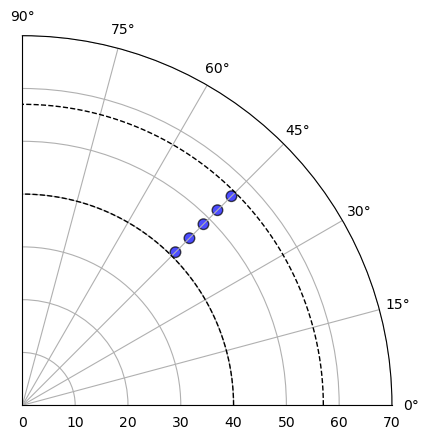

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Set up polar plot
fig, ax = plt.subplots(subplot_kw={'polar': True})
ax.set_aspect('equal')

# Parameters
theta_deg = 45
theta_rad = np.deg2rad(theta_deg)
r_start = 40
r_end = 57
num_circles = 5
circle_radius = 1.0
color = 'blue'

# Adjusted limits to avoid circles going past bounds
available_r_start = r_start + circle_radius
available_r_end = r_end - circle_radius

# Radial positions for circle centers
r_values = np.linspace(available_r_start, available_r_end, num_circles)

# Plot circles
for r in r_values:
    x = r * np.cos(theta_rad)
    y = r * np.sin(theta_rad)

    circle = patches.Circle(
        (x, y),
        radius=circle_radius,
        facecolor=color,
        edgecolor='black',
        alpha=0.7
    )
    ax.add_patch(circle)
    circle.set_transform(ax.transData._b)

# Plot boundary arcs (optional)
theta = np.linspace(0, np.pi / 2, 300)
ax.plot(theta, np.full_like(theta, r_start), 'k--', lw=1)
ax.plot(theta, np.full_like(theta, r_end), 'k--', lw=1)

# Polar plot settings
ax.set_thetamin(0)
ax.set_thetamax(90)
ax.set_rlim(0, 70)
ax.set_xticks(np.deg2rad(np.arange(0, 91, 15)))
ax.grid(True)

#plt.title("Non-overlapping Circles Between r_start and r_end at θ = 45°")
plt.show()


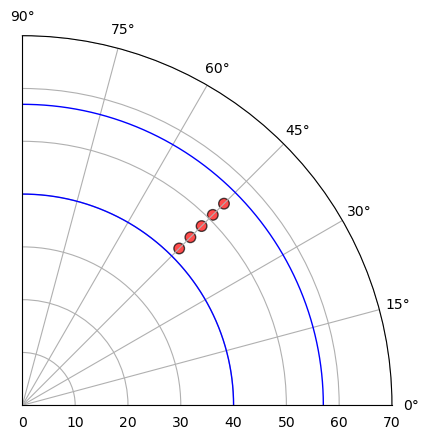

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Set up polar plot
fig, ax = plt.subplots(subplot_kw={'polar': True})
ax.set_aspect('equal')

# ---- User Settings ----
theta_deg = 45
r_start = 40
r_end = 57
num_circles = 5
circle_radius = 1.0
gap_between_circles = 1.0   # Radial gap *between* circles (edge to edge)
edge_gap = 1.0               # Radial gap *from boundaries* to nearest circle (edge to edge)
color = 'red'
# ------------------------

theta_rad = np.deg2rad(theta_deg)

# Total space taken up by circles and gaps
total_gap_space = (num_circles - 1) * gap_between_circles
total_circle_space = 2 * circle_radius * num_circles
required_space = 2 * edge_gap + total_gap_space + total_circle_space

# Check if available space is enough
available_space = r_end - r_start
if required_space > available_space:
    raise ValueError(f"Not enough space: Need {required_space}, but only {available_space} available.")

# Compute the center positions of the circles
# Start from r_start + edge_gap + circle_radius
first_center = r_start + edge_gap + circle_radius
r_values = [first_center + i * (2 * circle_radius + gap_between_circles) for i in range(num_circles)]

# Plot circles
for r in r_values:
    x = r * np.cos(theta_rad)
    y = r * np.sin(theta_rad)

    circle = patches.Circle(
        (x, y),
        radius=circle_radius,
        facecolor=color,
        edgecolor='black',
        alpha=0.7
    )
    ax.add_patch(circle)
    circle.set_transform(ax.transData._b)

# Optional: plot reference arcs
theta = np.linspace(0, np.pi / 2, 300)
ax.plot(theta, np.full_like(theta, r_start), lw=1, color='blue')
ax.plot(theta, np.full_like(theta, r_end), lw=1, color='blue')

# Polar plot settings
ax.set_thetamin(0)
ax.set_thetamax(90)
ax.set_rlim(0, 70)
ax.set_xticks(np.deg2rad(np.arange(0, 91, 15)))
ax.grid(True)

#plt.title("Custom-Spaced Circles in Polar Plot")
plt.show()


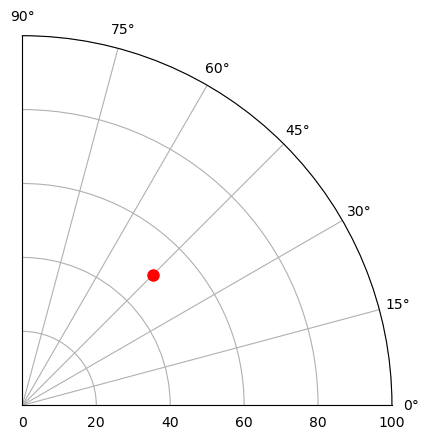

In [10]:
# Field at a point due to wire currents - Next goal
# The field of a wire is azimuthal in its dependence

import matplotlib.pyplot as plt
import numpy as np

# Create a polar subplot
fig, ax = plt.subplots(subplot_kw={'polar': True})

# Define your point (theta in radians, r in units)
theta = np.deg2rad(45)   # 45 degrees → π/4 radians
r = 50                   # Radius (distance from center)

# Plot the point
ax.plot(theta, r, 'ro', markersize=8)  # 'ro' = red circle

# Optional: customize plot
ax.set_rlim(0, 100)  # Set radial limit
ax.set_thetamin(0)
ax.set_thetamax(90)
ax.grid(True)

plt.show()


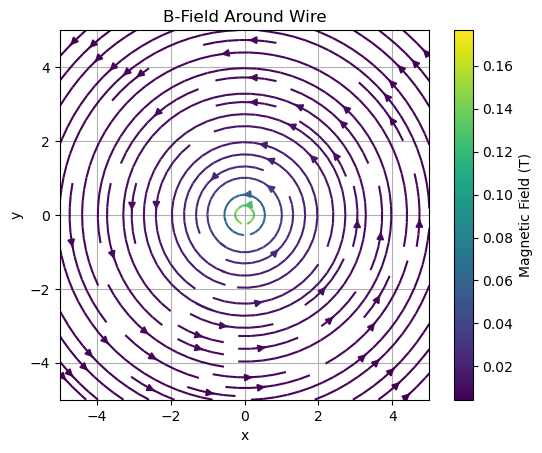

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Physical constants
mu0 = 4 * np.pi * 1e-7  # T·m/A
I = 160000  # Current in Amps

# Grid setup in x-y plane
x = np.linspace(-5, 5, 40)
y = np.linspace(-5, 5, 40)
X, Y = np.meshgrid(x, y) # Create a grid of all possible points
R = np.sqrt(X**2 + Y**2)

# Avoid division by zero at the wire's location
R[R == 0] = 1e-10

# B-field magnitude
B = (mu0 * I) / (2 * np.pi * R)

# Direction: tangential (circular around wire)
Bx = -B * Y / R
By = B * X / R

# Plot
#plt.figure(figsize=(6, 6))
plt.streamplot(X, Y, Bx, By, color=B, cmap='viridis')
plt.title("B-Field Around Wire")
plt.xlabel('x')
plt.ylabel('y')
plt.gca().set_aspect('equal')
plt.colorbar(label='Magnetic Field (T)')
plt.grid(True)
plt.show()


In [12]:
# Now we want to do this same process for a "block" of conductor points

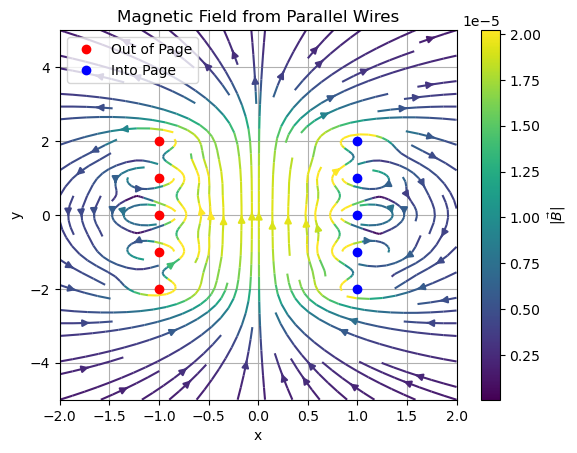

In [13]:
# Constants
mu0 = 4 * np.pi * 1e-7

# Creats a space for all x and y points in a 1D list
x = np.linspace(-2, 2, 1000)
y = np.linspace(-5, 5, 1000)

# Meshgrid defines all the points in the grid
# Turns the 1D linspace into a coordinate matrix of x and y points
X, Y = np.meshgrid(x, y)

# Calculates the magnetic field of a wire for a given (x, y) point and a given current
def wire_field(x, y, I):
    dx = X - x # Horrizontal distance from given point to each point on grid (like the shift h of a function: f(x)=m (x-h) + b)
    dy = Y - y # Vertical distance from given point to each point on grid
    R=np.sqrt(dx**2 + dy**2) # Gives the radial distance away from the given point to all other points

    B=(mu0 * I) / (2 * np.pi * R) # B-field from Ampere's Law
    
    # x and y components derived from the polar transformations
    Bx = (-B*dy)/(R)
    By = (B*dx)/(R)
    return Bx, By # Returns the set of x and y components for all of the defined space
    
# Now, we want to add up the field from a bunch of points:

# Need to initialize a zero array of the same size as X and Y respectively
Bx_total = np.zeros_like(X)
By_total = np.zeros_like(Y)

# Parameters are: (x, y, I), where I is in amps
# Positive currents are into the page
parameters = [
              # Out of page currents (+Z axis)
              (-1, -2, 20), 
              (-1, -1, 20), 
              (-1, 0, 20), 
              (-1, 1, 20),
              (-1, 2, 20),  
              # Into page currents (-Z axis)
              (1, -2, -20), 
              (1, -1, -20),
              (1, 0, -20),
              (1, 1, -20),
              (1, 2, -20)
             ]

for x, y, I in parameters:
    Bx, By = wire_field(x, y, I)
    # Calculates the total field in the x and y directions by adding up each vector space
    Bx_total += Bx
    By_total += By

# Calculate the array of B magnitude values in the space
B_mag = np.sqrt(Bx_total**2 + By_total**2)

####################################################################################################

# Plot streamlines

# Normalize using actual min/max of the data
#norm = mcolors.Normalize(vmin=magnitude.min(), vmax=magnitude.max())

# Normalization is maxxed at the 95th percentile so we can actually see the relative strength at the origin more clearly
norm = mcolors.Normalize(vmin=B_mag.min(), vmax=np.percentile(B_mag, 95))

# Plot streamlines with normalized color mapping
strm = plt.streamplot(X, Y, Bx_total, By_total, color=B_mag, cmap='viridis', norm=norm)

# Add colorbar
plt.colorbar(strm.lines, label='$|\\vec{B}|$')

# Plots wire positions

# Out of page wires
plt.plot(-1, -2, 'ro', label='Out of Page')
plt.plot(-1, -1, 'ro')
plt.plot(-1, 0, 'ro')
plt.plot(-1, 1, 'ro')
plt.plot(-1, 2, 'ro')

# Into page wires
plt.plot(1, -2, 'bo', label='Into Page')
plt.plot(1, -1, 'bo')
plt.plot(1, 0, 'bo')
plt.plot(1, 1, 'bo')
plt.plot(1, 2, 'bo')

plt.legend(loc='upper left')
plt.title("Magnetic Field from Parallel Wires")
#plt.xlim(-0.5, 1.5)
#plt.ylim(-0.5, 0.5)
plt.xlabel("x")
plt.ylabel("y")
#plt.axis('equal')
plt.grid(True)
#plt.colorbar(label='Magnitude of B')
#plt.savefig('WireBField.pdf')
plt.show()


In [14]:
# Now, try to get field from block configuration of wires maybe?
# Can also try to add in harmonic terms for x and y components of B

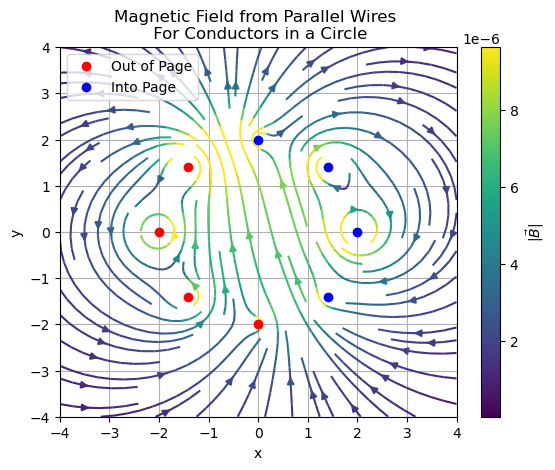

In [15]:
# Constants
mu0 = 4 * np.pi * 1e-7

# Creats a space for all x and y points in a 1D list
x = np.linspace(-4, 4, 1000)
y = np.linspace(-4, 4, 1000)

# Meshgrid defines all the points in the grid
# Turns the 1D linspace into a coordinate matrix of x and y points
X, Y = np.meshgrid(x, y)

# Calculates the magnetic field of a wire for a given (x, y) point and a given current
def wire_field(x, y, I):
    dx = X - x # Horrizontal distance from given point to each point on grid (like the shift h of a function: f(x)=m (x-h) + b)
    dy = Y - y # Vertical distance from given point to each point on grid
    R=np.sqrt(dx**2 + dy**2) # Gives the radial distance away from the given point to all other points

    B=(mu0 * I) / (2 * np.pi * R) # B-field from Ampere's Law
    
    # x and y components derived from the polar transformations
    Bx = (-B*dy)/(R)
    By = (B*dx)/(R)
    return Bx, By # Returns the set of x and y components for all of the defined space
    
# Now, we want to add up the field from a bunch of points:

# Need to initialize a zero array of the same size as X and Y respectively
Bx_total = np.zeros_like(X)
By_total = np.zeros_like(Y)

# Parameters are: (x, y, I), where I is in amps
# Positive currents are into the page
parameters = [
              # Out of page currents (+Z axis)

              (-1.41, 1.41, 20),
              (-2.0, 0.0, 20*0.75), 
              (-1.41, -1.41, 20*0.5),
              (0.0, -2.0, 20*0.25), 
               
                
              # Into page currents (-Z axis)
              (2.0, 0.0, -20), 
              (1.41, 1.41, -20*0.75),
              (0.0, 2.0, -20*0.50),
              (1.41, -1.41, -20*0.25)
             ]

for x, y, I in parameters:
    Bx, By = wire_field(x, y, I)
    # Calculates the total field in the x and y directions by adding up each vector space
    Bx_total += Bx
    By_total += By

# Calculate the array of B magnitude values in the space
B_mag = np.sqrt(Bx_total**2 + By_total**2)

####################################################################################################

# Plot streamlines

# Normalize using actual min/max of the data
#norm = mcolors.Normalize(vmin=magnitude.min(), vmax=magnitude.max())

# Normalization is maxxed at the 95th percentile so we can actually see the relative strength at the origin more clearly
norm = mcolors.Normalize(vmin=B_mag.min(), vmax=np.percentile(B_mag, 95))

# Plot streamlines with normalized color mapping
strm = plt.streamplot(X, Y, Bx_total, By_total, color=B_mag, cmap='viridis', norm=norm)

# Add colorbar
plt.colorbar(strm.lines, label='$|\\vec{B}|$')

# Plots wire positions

# Out of page wires (left side)
plt.plot(-1.41, 1.41, 'ro')
plt.plot(-2.0, 0.0, 'ro', label='Out of Page')
plt.plot(-1.41, -1.41, 'ro')
plt.plot(0.0, -2.0, 'ro')

# Into page wires (right side)
plt.plot(2.0, 0.0, 'bo', label='Into Page')
plt.plot(1.41, 1.41, 'bo')
plt.plot(0.0, 2.0, 'bo')
plt.plot(1.41, -1.41, 'bo')



plt.legend(loc='upper left')
plt.title("Magnetic Field from Parallel Wires \n For Conductors in a Circle")
#plt.xlim(-0.5, 1.5)
#plt.ylim(-0.5, 0.5)
plt.xlabel("x")
plt.ylabel("y")
#plt.axis('equal')
plt.grid(True)
#plt.colorbar(label='Magnitude of B')
#plt.savefig('WireBField.pdf')
plt.show()


$\theta=\arctan (\frac{y}{x})$

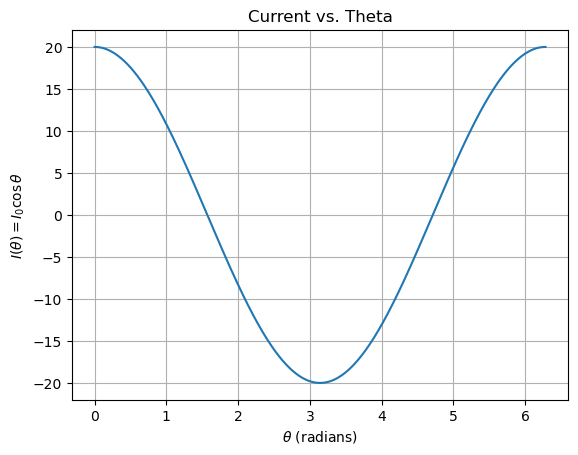

In [16]:
# Here we define a function to deal with the cosine theta magnet current
# I0 is the max current

I0 = 20
theta = np.linspace(0, 2*np.pi, 400)
I_theta = I0 * np.cos(theta)

plt.plot(theta, I_theta)
plt.title('Current vs. Theta')
plt.xlabel('$\\theta$ (radians)')
plt.ylabel('$I(\\theta)=I_0\\cos\\theta$')
plt.grid(True)
plt.show()
    

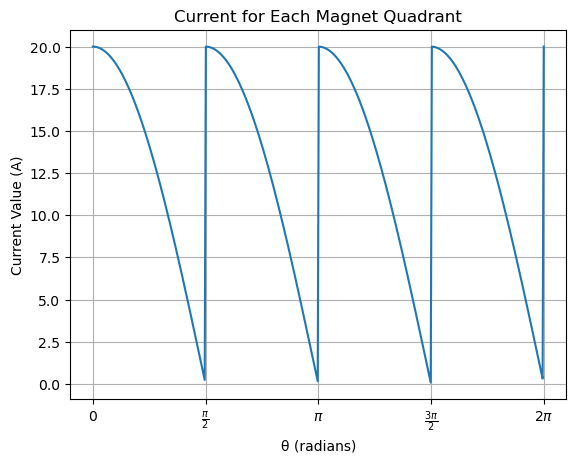

In [17]:
I0 = 20
theta = np.linspace(0, 2*np.pi, 400)

# Fold theta into intervals of pi/2 (i.e., reset every 90°)
theta_folded = theta % (np.pi / 2)

# Compute I(theta) with reset every 90°
I_theta = I0 * np.cos(theta_folded)

# Plot
plt.plot(theta, I_theta)
plt.title('Current for Each Magnet Quadrant')
plt.xlabel('θ (radians)')
plt.ylabel('Current Value (A)')
plt.grid(True)

# Optional: Label 90° ticks
plt.xticks(
    np.linspace(0, 2*np.pi, 5),
    ['0', '$\\frac{\\pi}{2}$', '$\\pi$', '$\\frac{3\\pi}{2}$', '$2\\pi$']
)

plt.show()


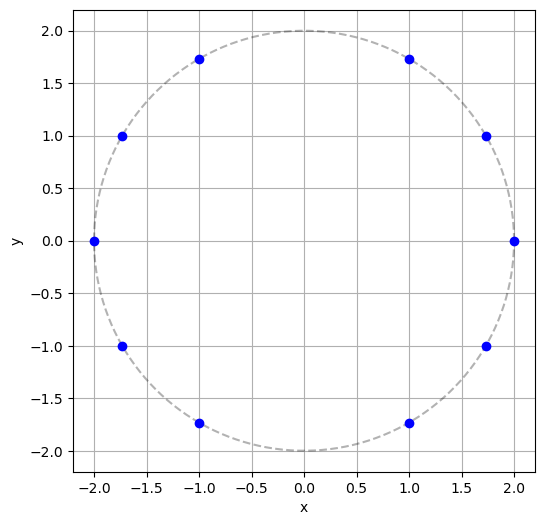

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
radius = 2
num_points = 12  # total number of points before filtering

# Generate full set of angles
theta = np.linspace(0, 2*np.pi, num_points, endpoint=False)

# Filter out top (π/2) and bottom (3π/2)
# Use a small threshold to avoid floating point errors
epsilon = 1e-5
theta_filtered = theta[
    (np.abs(theta - np.pi/2) > epsilon) & 
    (np.abs(theta - 3*np.pi/2) > epsilon)
]

# Convert to Cartesian coordinates
x = radius * np.cos(theta_filtered)
y = radius * np.sin(theta_filtered)

# --- Plotting ---
plt.figure(figsize=(6,6))

# Plot the circle outline
theta_circle = np.linspace(0, 2*np.pi, 500)
x_circle = radius * np.cos(theta_circle)
y_circle = radius * np.sin(theta_circle)
plt.plot(x_circle, y_circle, 'k--', alpha=0.3)

# Plot the filtered points
plt.plot(x, y, 'bo')

# Optionally label the angle
#for i in range(len(theta_filtered)):
#    angle_deg = np.degrees(theta_filtered[i]) % 360
#    plt.text(x[i]*1.1, y[i]*1.1, f"{angle_deg:.0f}°", ha='center', va='center')

plt.gca().set_aspect('equal')
#plt.title('Points Around Circle (No Top/Bottom)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
#plt.legend()
plt.show()


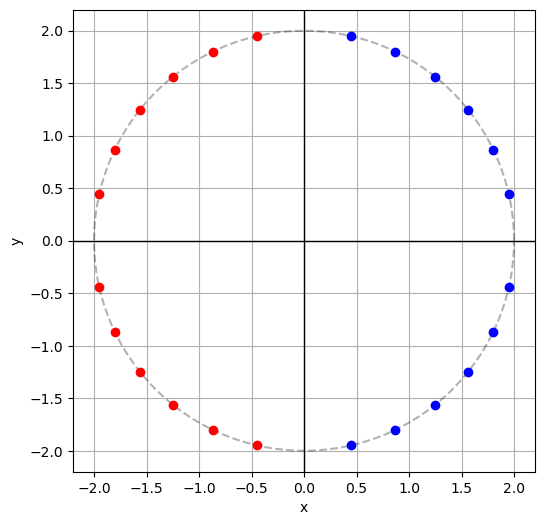

In [19]:
# --- Parameters ---
radius = 2

# Number of points per quadrant (excluding boundaries)
points_per_quadrant = 6  # e.g., 3 per quadrant gives 12 total (excluding boundary angles)

# Excluded angles in radians: 0°, 90°, 180°, 270°
excluded_angles = [0, np.pi/2, np.pi, 3*np.pi/2]
epsilon = 1e-5  # Tolerance for floating point comparisons

# --- Build angles ---
quadrants = [
    (0, np.pi/2),
    (np.pi/2, np.pi),
    (np.pi, 3*np.pi/2),
    (3*np.pi/2, 2*np.pi)
]

theta_list = []

for q_start, q_end in quadrants:
    theta_segment = np.linspace(q_start, q_end, points_per_quadrant + 2)[1:-1]  # exclude edges
    theta_list.extend(theta_segment)

theta_all = np.array(theta_list)

# Remove any angles close to the excluded ones
theta_filtered = np.array([
    angle for angle in theta_all
    if all(np.abs(angle - ex) > epsilon for ex in excluded_angles)
])

# --- Convert to Cartesian ---
x = radius * np.cos(theta_filtered)
y = radius * np.sin(theta_filtered)

# --- Plotting ---
plt.figure(figsize=(6, 6))

# Circle outline
circle_theta = np.linspace(0, 2*np.pi, 500)
x_circle = radius * np.cos(circle_theta)
y_circle = radius * np.sin(circle_theta)
plt.plot(x_circle, y_circle, 'k--', alpha=0.3)

# Plot points with color depending on quadrant
for xi, yi in zip(x, y):
    if xi > 0:  # Quadrants I and IV
        color = 'b'
    elif xi < 0:  # Quadrants II and III
        color = 'r'
    else:
        color = 'k'  # Edge case (on y-axis, should be excluded)

    plt.plot(xi, yi, 'o', color=color)

# Plotting axes
plt.axhline(0, color='black', linewidth=1)  # x-axis
plt.axvline(0, color='black', linewidth=1)  # y-axis

plt.gca().set_aspect('equal')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()


[0.17453292519943295, 0.3490658503988659, 0.5235987755982988, 0.6981317007977318, 0.8726646259971648, 1.0471975511965976, 1.2217304763960306, 1.3962634015954636, 1.7453292519943295, 1.9198621771937625, 2.0943951023931953, 2.2689280275926285, 2.443460952792061, 2.617993877991494, 2.792526803190927, 2.9670597283903604, 3.316125578789226, 3.490658503988659, 3.665191429188092, 3.839724354387525, 4.014257279586958, 4.1887902047863905, 4.363323129985824, 4.537856055185257, 4.886921905584122, 5.061454830783555, 5.235987755982989, 5.410520681182422, 5.585053606381854, 5.759586531581287, 5.934119456780721, 6.1086523819801535]


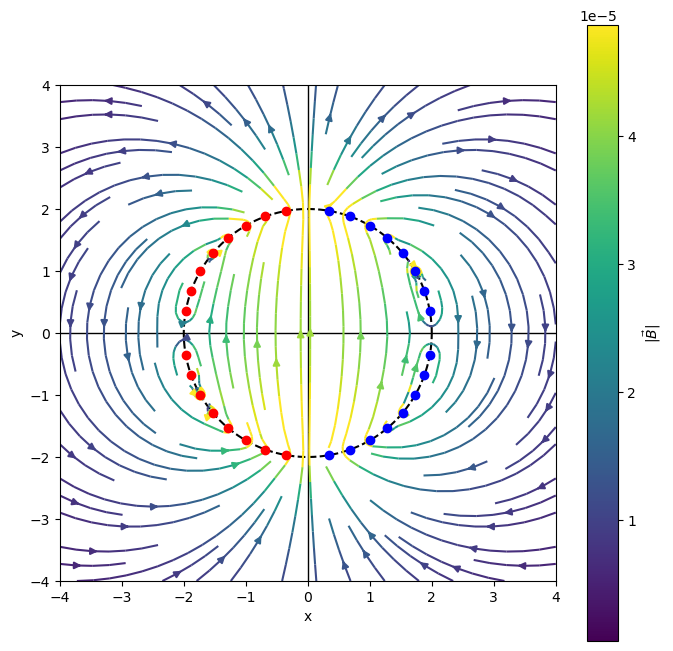

In [20]:
# Constants
mu0 = 4 * np.pi * 1e-7  # Vacuum permeability
radius = 2 # Radius from origin as starting point
points_per_quadrant = 8
excluded_angles = [0, np.pi/2, np.pi, 3*np.pi/2]
I0 = 20  # current magnitude

#######################################################

# Create meshgrid for field calculation
x_grid = np.linspace(-4, 4, 400)
y_grid = np.linspace(-4, 4, 400)
X, Y = np.meshgrid(x_grid, y_grid)

# We define the field calculation from Ampere's Law for a wire
def wire_field(x, y, I):
    dx = X - x
    dy = Y - y
    R = np.sqrt(dx**2 + dy**2)
    
    # Avoid divide by zero at wire location
    R[R == 0] = 1e-10
    
    B = (mu0 * I) / (2 * np.pi * R)
    Bx = (-B * dy) / R
    By = (B * dx) / R
    return Bx, By

# Here we define each quandrant of the magnet
quadrants = [
    (0, np.pi/2),
    (np.pi/2, np.pi),
    (np.pi, 3*np.pi/2),
    (3*np.pi/2, 2*np.pi)
]

# Here, we generate evenly spaced angles
theta_list = []
for q_start, q_end in quadrants:
    theta_segment = np.linspace(q_start, q_end, points_per_quadrant + 2)[1:-1]
    theta_list.extend(theta_segment)
print(theta_list)

# Here, we filter out any angles close to the axes
epsilon = 1e-5
theta_all = np.array(theta_list)
theta_filtered = np.array([angle for angle in theta_all if all(np.abs(angle - ex) > epsilon for ex in excluded_angles)])
# We could also filter angles explcitly, thus allowing us to exclude some angles

# Convert to Cartesian
x = radius * np.cos(theta_filtered)
y = radius * np.sin(theta_filtered)

# Assign current based on quadrant (via x sign)
wire_params = []

for xi, yi in zip(x, y):
    if xi > 0:  # Q1 and Q4 → into page
        current = -I0
    elif xi < 0:  # Q2 and Q3 → out of page
        current = I0
    else:
        current = 0  # shouldn't occur
    wire_params.append((xi, yi, current))

# Total Field Calculation
Bx_total = np.zeros_like(X)
By_total = np.zeros_like(Y)

for x0, y0, I in wire_params:
    Bx, By = wire_field(x0, y0, I)
    Bx_total += Bx
    By_total += By

B_mag = np.sqrt(Bx_total**2 + By_total**2)

#######################################################

# Plotting
plt.figure(figsize=(8, 8))

# Normalize color scale to 95th percentile
norm = mcolors.Normalize(vmin=B_mag.min(), vmax=np.percentile(B_mag, 95))

# Plot streamlines
strm = plt.streamplot(X, Y, Bx_total, By_total, color=B_mag, cmap='viridis', norm=norm)
plt.colorbar(strm.lines, label='$|\\vec{B}|$')

# Plot wire positions with color by direction
for x0, y0, I in wire_params:
    color = 'r' if I > 0 else 'b'
    plt.plot(x0, y0, 'o', color=color)

# Plot the circle outline
theta_circle = np.linspace(0, 2*np.pi, 500)
x_circle = radius * np.cos(theta_circle)
y_circle = radius * np.sin(theta_circle)
plt.plot(x_circle, y_circle, 'k--', zorder=0)

# Plot x and y axes
plt.axhline(0, color='black', linewidth=1, zorder=0)
plt.axvline(0, color='black', linewidth=1, zorder=0)

# Final plot settings
plt.gca().set_aspect('equal')
plt.xlabel("x")
plt.ylabel("y")
#plt.grid(True)
plt.show()


theta_list (radians):
[-1.08241101 -0.87215647 -0.70529255 -0.55947938 -0.42596162 -0.30010429
 -0.17897197 -0.06042986  0.05728512  0.17582723  0.29695955  0.42281688
  0.55633465  0.70214782  0.86901173  1.07926627  2.06232638  2.27258092
  2.43944484  2.58525801  2.71877577  2.8446331   2.96576542  3.08430753
  3.20202251  3.32056462  3.44169694  3.56755427  3.70107204  3.84688521
  4.01374912  4.22400366]


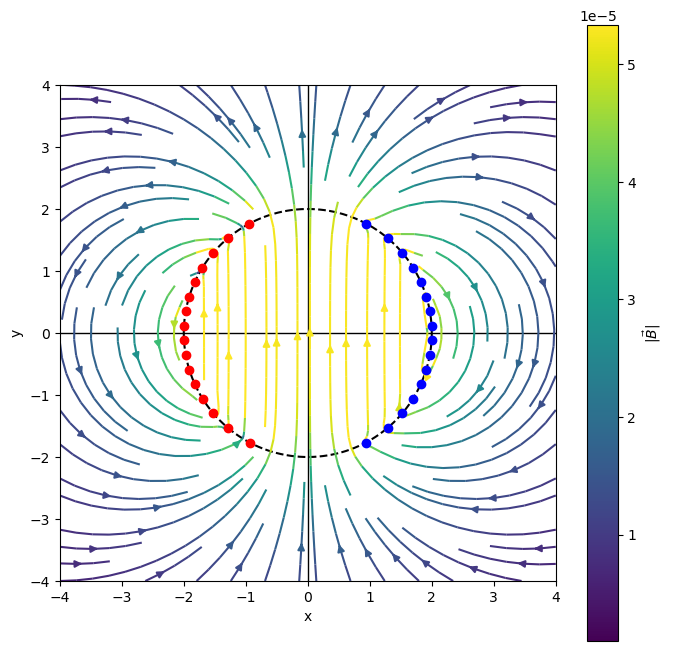

In [21]:
# Constants
mu0 = 4 * np.pi * 1e-7  # Vacuum permeability
radius = 2 # Radius from origin as starting point
points_per_quadrant = 8
excluded_angles = [0, np.pi/2, np.pi, 3*np.pi/2]
I0 = 20  # current magnitude

#######################################################

# Create meshgrid for field calculation
x_grid = np.linspace(-4, 4, 400)
y_grid = np.linspace(-4, 4, 400)
X, Y = np.meshgrid(x_grid, y_grid)

# We define the field calculation from Ampere's Law for a wire
def wire_field(x, y, I):
    dx = X - x
    dy = Y - y
    R = np.sqrt(dx**2 + dy**2)
    
    # Avoid divide by zero at wire location
    R[R == 0] = 1e-10
    
    B = (mu0 * I) / (2 * np.pi * R)
    Bx = (-B * dy) / R
    By = (B * dx) / R
    return Bx, By

# Here we define each quandrant of the magnet
quadrants = [
    (0, np.pi/2),
    (np.pi/2, np.pi),
    (np.pi, 3*np.pi/2),
    (3*np.pi/2, 2*np.pi)
]

# Parameters
I0 = 20
num_points = 1000
num_conductors = 32  # Total conductors
half_conductors = num_conductors // 2

# θ in [-π/2, π/2] (right half of circle around x-axis)
theta_half = np.linspace(-np.pi/2, np.pi/2, num_points)
I_theta_half = I0 * np.cos(theta_half)  # Peaks at 0, drops off at ±π/2

# Normalize PDF
pdf_half = I_theta_half / np.sum(I_theta_half)
cdf_half = np.cumsum(pdf_half)

# Uniform samples (avoid edges)
u = np.linspace(0, 1, half_conductors + 2)[1:-1]

# Sample θs in [-π/2, π/2]
theta_right = np.interp(u, cdf_half, theta_half)

# Mirror into left half: θ ↦ π - θ
theta_left = np.pi - theta_right

# Combine and sort
theta_list = np.sort(np.concatenate([theta_right, theta_left]))

print("theta_list (radians):")
print(theta_list)




# Here, we filter out any angles close to the axes
epsilon = 1e-5
theta_all = np.array(theta_list)
theta_filtered = np.array([angle for angle in theta_all if all(np.abs(angle - ex) > epsilon for ex in excluded_angles)])
# We could also filter angles explcitly, thus allowing us to exclude some angles

# Convert to Cartesian
x = radius * np.cos(theta_filtered)
y = radius * np.sin(theta_filtered)

# Assign current based on quadrant (via x sign)
wire_params = []

for xi, yi in zip(x, y):
    if xi > 0:  # Q1 and Q4 → into page
        current = -I0
    elif xi < 0:  # Q2 and Q3 → out of page
        current = I0
    else:
        current = 0  # shouldn't occur
    wire_params.append((xi, yi, current))

# Total Field Calculation
Bx_total = np.zeros_like(X)
By_total = np.zeros_like(Y)

for x0, y0, I in wire_params:
    Bx, By = wire_field(x0, y0, I)
    Bx_total += Bx
    By_total += By

B_mag = np.sqrt(Bx_total**2 + By_total**2)

#######################################################

# Plotting
plt.figure(figsize=(8, 8))

# Normalize color scale to 95th percentile
norm = mcolors.Normalize(vmin=B_mag.min(), vmax=np.percentile(B_mag, 95))

# Plot streamlines
strm = plt.streamplot(X, Y, Bx_total, By_total, color=B_mag, cmap='viridis', norm=norm)
plt.colorbar(strm.lines, label='$|\\vec{B}|$')

# Plot wire positions with color by direction
for x0, y0, I in wire_params:
    color = 'r' if I > 0 else 'b'
    plt.plot(x0, y0, 'o', color=color)

# Plot the circle outline
theta_circle = np.linspace(0, 2*np.pi, 500)
x_circle = radius * np.cos(theta_circle)
y_circle = radius * np.sin(theta_circle)
plt.plot(x_circle, y_circle, 'k--', zorder=0)

# Plot x and y axes
plt.axhline(0, color='black', linewidth=1, zorder=0)
plt.axvline(0, color='black', linewidth=1, zorder=0)

# Final plot settings
plt.gca().set_aspect('equal')
plt.xlabel("x")
plt.ylabel("y")
#plt.grid(True)
plt.show()


theta_list (radians):
[-1.08241101 -0.87215647 -0.70529255 -0.55947938 -0.42596162 -0.30010429
 -0.17897197 -0.06042986  0.05728512  0.17582723  0.29695955  0.42281688
  0.55633465  0.70214782  0.86901173  1.07926627  2.06232638  2.27258092
  2.43944484  2.58525801  2.71877577  2.8446331   2.96576542  3.08430753
  3.20202251  3.32056462  3.44169694  3.56755427  3.70107204  3.84688521
  4.01374912  4.22400366]


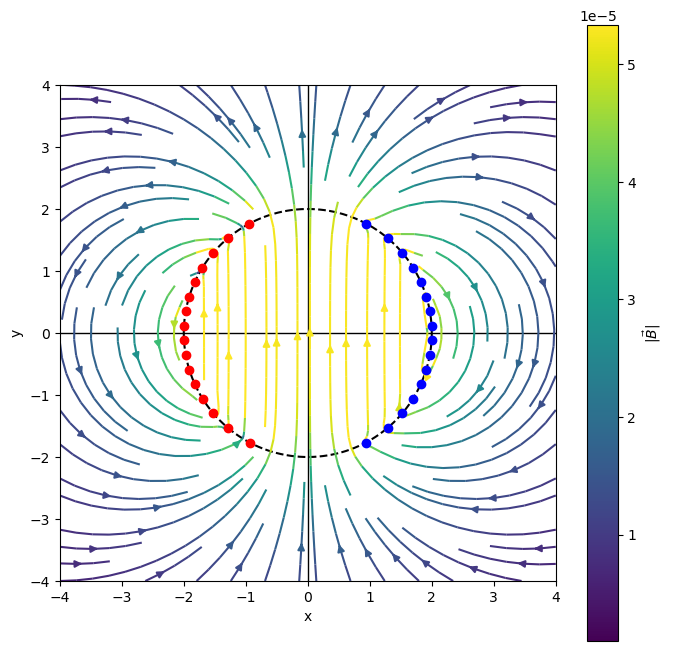

In [22]:
# Constants
mu0 = 4 * np.pi * 1e-7  # Vacuum permeability
radius = 2 # Radius from origin as starting point
points_per_quadrant = 8
excluded_angles = [0, np.pi/2, np.pi, 3*np.pi/2]
I0 = 20  # current magnitude

#######################################################

# Create meshgrid for field calculation
x_grid = np.linspace(-4, 4, 400)
y_grid = np.linspace(-4, 4, 400)
X, Y = np.meshgrid(x_grid, y_grid)

# We define the field calculation from Ampere's Law for a wire
def wire_field(x, y, I):
    dx = X - x
    dy = Y - y
    R = np.sqrt(dx**2 + dy**2)
    
    # Avoid divide by zero at wire location
    R[R == 0] = 1e-10
    
    B = (mu0 * I) / (2 * np.pi * R)
    Bx = (-B * dy) / R
    By = (B * dx) / R
    return Bx, By

# Here we define each quandrant of the magnet
quadrants = [
    (0, np.pi/2),
    (np.pi/2, np.pi),
    (np.pi, 3*np.pi/2),
    (3*np.pi/2, 2*np.pi)
]

# Parameters
I0 = 20
num_points = 1000
num_conductors = 32  # Total conductors
half_conductors = num_conductors // 2

# θ in [-π/2, π/2] (right half of circle around x-axis)
theta_half = np.linspace(-np.pi/2, np.pi/2, num_points)
I_theta_half = I0 * np.cos(theta_half)  # Peaks at 0, drops off at ±π/2

# Normalize PDF
pdf_half = I_theta_half / np.sum(I_theta_half)
cdf_half = np.cumsum(pdf_half)

# Uniform samples (avoid edges)
u = np.linspace(0, 1, half_conductors + 2)[1:-1]

# Sample θs in [-π/2, π/2]
theta_right = np.interp(u, cdf_half, theta_half)

# Mirror into left half: θ ↦ π - θ
theta_left = np.pi - theta_right

# Combine and sort
theta_list = np.sort(np.concatenate([theta_right, theta_left]))

print("theta_list (radians):")
print(theta_list)




# Here, we filter out any angles close to the axes
epsilon = 1e-5
theta_all = np.array(theta_list)
theta_filtered = np.array([angle for angle in theta_all if all(np.abs(angle - ex) > epsilon for ex in excluded_angles)])
# We could also filter angles explcitly, thus allowing us to exclude some angles

# Convert to Cartesian
x = radius * np.cos(theta_filtered)
y = radius * np.sin(theta_filtered)

# Assign current based on quadrant (via x sign)
wire_params = []

for xi, yi in zip(x, y):
    if xi > 0:  # Q1 and Q4 → into page
        current = -I0
    elif xi < 0:  # Q2 and Q3 → out of page
        current = I0
    else:
        current = 0  # shouldn't occur
    wire_params.append((xi, yi, current))

# Total Field Calculation
Bx_total = np.zeros_like(X)
By_total = np.zeros_like(Y)

for x0, y0, I in wire_params:
    Bx, By = wire_field(x0, y0, I)
    Bx_total += Bx
    By_total += By

B_mag = np.sqrt(Bx_total**2 + By_total**2)

#######################################################

# Plotting
plt.figure(figsize=(8, 8))

# Normalize color scale to 95th percentile
norm = mcolors.Normalize(vmin=B_mag.min(), vmax=np.percentile(B_mag, 95))

# Plot streamlines
strm = plt.streamplot(X, Y, Bx_total, By_total, color=B_mag, cmap='viridis', norm=norm)
plt.colorbar(strm.lines, label='$|\\vec{B}|$')

# Plot wire positions with color by direction
for x0, y0, I in wire_params:
    color = 'r' if I > 0 else 'b'
    plt.plot(x0, y0, 'o', color=color)

# Plot the circle outline
theta_circle = np.linspace(0, 2*np.pi, 500)
x_circle = radius * np.cos(theta_circle)
y_circle = radius * np.sin(theta_circle)
plt.plot(x_circle, y_circle, 'k--', zorder=0)

# Plot x and y axes
plt.axhline(0, color='black', linewidth=1, zorder=0)
plt.axvline(0, color='black', linewidth=1, zorder=0)

# Final plot settings
plt.gca().set_aspect('equal')
plt.xlabel("x")
plt.ylabel("y")
#plt.grid(True)
plt.show()


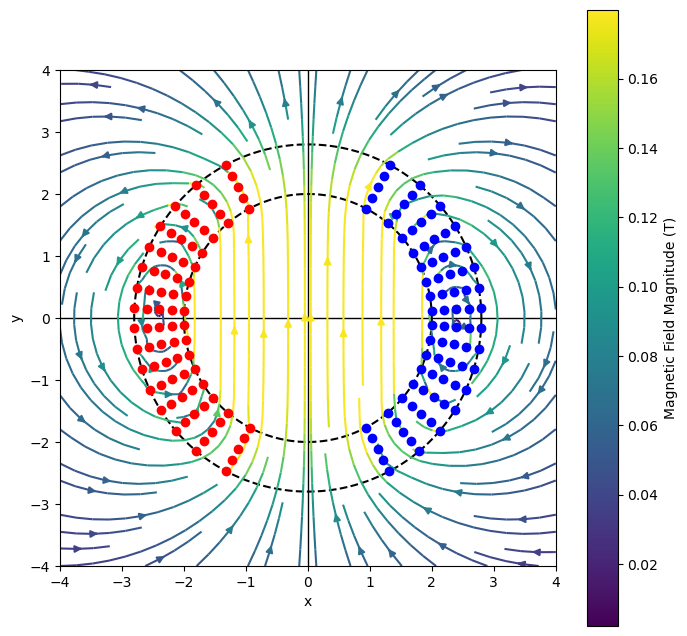

In [31]:
# Constants
mu0 = 4 * np.pi * 1e-7 # Vacuum permeability
radius = 2 # Radius from origin as starting point (inner layer)
# Outter radius is controlled by amount of condutors present in block
num_conductors = 32 # Total number of blocks (divide by 4 to get number of blocks per quadrant)
n_radial = 5 # Number of conductors per block
dr = 0.2 # Radial spacing of conductors
excluded_angles = [0, np.pi/2, np.pi, 3*np.pi/2] # Angles where we do not want points to lie on
I0 = 16000 # Current magnitude

# Grid for field calculation
x_grid = np.linspace(-4, 4, 400)
y_grid = np.linspace(-4, 4, 400)
X, Y = np.meshgrid(x_grid, y_grid)

# Biot-Savart field from a wire
def wire_field(x, y, I):
    dx = X - x
    dy = Y - y
    R = np.sqrt(dx**2 + dy**2)
    R[R == 0] = 1e-10  # Prevent divide by zero
    B = (mu0 * I) / (2 * np.pi * R)
    Bx = (-B * dy) / R
    By = (B * dx) / R
    return Bx, By

# List of angles following a cosine theta distribution, symmetric about y axis
half_conductors = num_conductors // 2 # Total number of conductors per side

theta_half = np.linspace(-np.pi/2, np.pi/2, 1000) # Creates a linspace of the right side of the magnet (quadrants 1 and 4), 1000 is the number of values in the linspace
I_theta_half = I0 * np.cos(theta_half) # Calculates the current for each of these points in the right side


# pdf/cdf allows you to space things according to a desired density function
pdf_half = I_theta_half / np.sum(I_theta_half)  # Define a probability-like distribution representing how densely points should be spaced
cdf_half = np.cumsum(pdf_half)  # Convert this distribution into a cumulative sum (CDF), which lets us map uniform samples to angles weighted by this distribution
# Used for inverse transform sampling: mapping uniform samples to a desired distribution

# Creates a space of points in the interval (0,1), where the number of points is half the total conductors we have
# The line [1:-1] ensures we do not include 0 and 1

# Inverses the CDF to get the points
u = np.linspace(0, 1, half_conductors + 2)[1:-1]

# Interp takes: points, x values, y values
theta_right = np.interp(u, cdf_half, theta_half) # Right side of plot
theta_left = np.pi - theta_right # Reflection to left side of plot

theta_list = np.sort(np.concatenate([theta_right, theta_left]))


# Filter excluded angles from the list of where points can be plotted
epsilon = 1e-5
theta_filtered = np.array([
    angle for angle in theta_list
    if all(np.abs(angle - ex) > epsilon for ex in excluded_angles)
])

# Determines the position of the conductors from the given angles
r0 = radius # Inner radius

radii = [r0 + i * dr for i in range(n_radial)]

# Compute conductor positions (x, y, I)
wire_params = []

for theta in theta_filtered:
    for r in radii:
        x = r * np.cos(theta)
        y = r * np.sin(theta)

        # Determine current direction by quadrant
        if x > 0:
            current = -I0  # Q1 & Q4 (right side)
        elif x < 0:
            current = I0   # Q2 & Q3 (left side)
        else:
            current = 0  # Edge case — not expected
        wire_params.append((x, y, current))

# B-field components are computed
Bx_total = np.zeros_like(X)
By_total = np.zeros_like(Y)

for x0, y0, I in wire_params:
    Bx, By = wire_field(x0, y0, I)
    Bx_total += Bx
    By_total += By

# Total B-field magnitudes are computed
B_mag = np.sqrt(Bx_total**2 + By_total**2)

####################################################################################
# Plotting

plt.figure(figsize=(8, 8))
# Only shows 95th percentile as max to make line magnitudes easier to see
norm = mcolors.Normalize(vmin=B_mag.min(), vmax=np.percentile(B_mag, 95)) 

# Stream plot of magnetic field
strm = plt.streamplot(X, Y, Bx_total, By_total, color=B_mag, cmap='viridis', norm=norm)
cbar = plt.colorbar(strm.lines, label='Magnetic Field Magnitude (T)')

# Plot conductors
for x0, y0, I in wire_params:
    color = 'r' if I > 0 else 'b'
    plt.plot(x0, y0, 'o', color=color)

# Draw inner circle (optional reference)
theta_circle = np.linspace(0, 2*np.pi, 500)
x_circle = radius * np.cos(theta_circle)
y_circle = radius * np.sin(theta_circle)
plt.plot(x_circle, y_circle, 'k--', zorder=0)

# Draw outer circle to contain all conductors (defined by number of conductors)
outer_radius = r0 + (n_radial - 1) * dr
theta_circle = np.linspace(0, 2 * np.pi, 500)
x_outer = outer_radius * np.cos(theta_circle)
y_outer = outer_radius * np.sin(theta_circle)
plt.plot(x_outer, y_outer, 'k--', zorder=0)

# Axes & final layout
plt.axhline(0, color='black', linewidth=1, zorder=0)
plt.axvline(0, color='black', linewidth=1, zorder=0)
plt.gca().set_aspect('equal')
plt.xlabel("x")
plt.ylabel("y")
#plt.title("")
plt.show()


In [24]:
# Now we extend to field harmonics

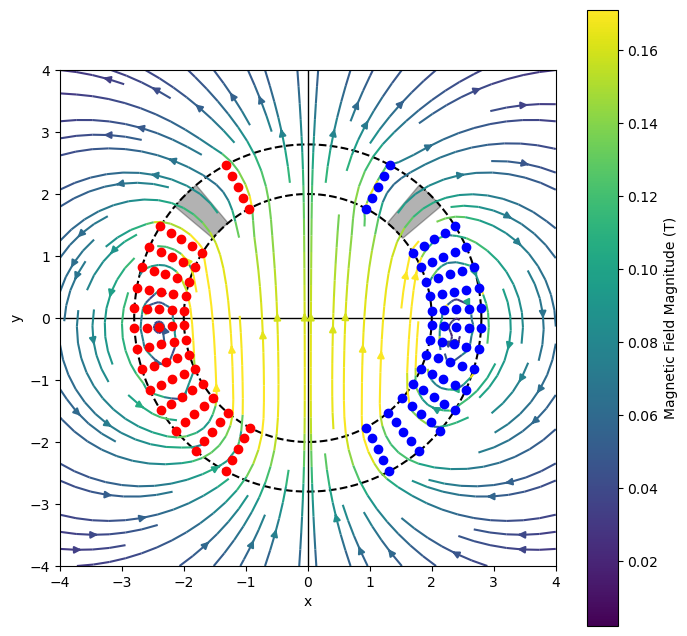

In [25]:
from matplotlib.patches import Wedge
# Constants
mu0 = 4 * np.pi * 1e-7 # Vacuum permeability
radius = 2 # Radius from origin as starting point (inner layer)
# Outter radius is controlled by amount of condutors present in block
num_conductors = 32 # Total number of blocks (divide by 4 to get number of blocks per quadrant)
n_radial = 5 # Number of conductors per block
dr = 0.2 # Radial spacing of conductors
excluded_angles = [0, np.pi/2, np.pi, 3*np.pi/2] # Angles where we do not want points to lie on
I0 = 16000 # Current magnitude

# Grid for field calculation
x_grid = np.linspace(-4, 4, 400)
y_grid = np.linspace(-4, 4, 400)
X, Y = np.meshgrid(x_grid, y_grid)

# Biot-Savart field from a wire
def wire_field(x, y, I):
    dx = X - x
    dy = Y - y
    R = np.sqrt(dx**2 + dy**2)
    R[R == 0] = 1e-10  # Prevent divide by zero
    B = (mu0 * I) / (2 * np.pi * R)
    Bx = (-B * dy) / R
    By = (B * dx) / R
    return Bx, By

# List of angles following a cosine theta distribution, symmetric about y axis
half_conductors = num_conductors // 2 # Total number of conductors per side

theta_half = np.linspace(-np.pi/2, np.pi/2, 1000) # Creates a linspace of the right side of the magnet (quadrants 1 and 4), 1000 is the number of values in the linspace
I_theta_half = I0 * np.cos(theta_half) # Calculates the current for each of these points in the right side


# pdf/cdf allows you to space things according to a desired density function
pdf_half = I_theta_half / np.sum(I_theta_half)  # Define a probability-like distribution representing how densely points should be spaced
cdf_half = np.cumsum(pdf_half)  # Convert this distribution into a cumulative sum (CDF), which lets us map uniform samples to angles weighted by this distribution
# Used for inverse transform sampling: mapping uniform samples to a desired distribution

# Creates a space of points in the interval (0,1), where the number of points is half the total conductors we have
# The line [1:-1] ensures we do not include 0 and 1
# Inverses the CDF to get the points
u = np.linspace(0, 1, half_conductors + 2)[1:-1]

# Interp takes: points, x values, y values
theta_right = np.interp(u, cdf_half, theta_half) # Right side of plot
theta_left = np.pi - theta_right # Reflection to left side of plot

theta_list = np.sort(np.concatenate([theta_right, theta_left]))

# Define wedge angular ranges (start, end) in degrees
wedge_regions = [
    (np.deg2rad(40), np.deg2rad(50)),   # Example: 40°–50°
    (np.deg2rad(130), np.deg2rad(140)), # Example: 130°–140°
]

# Helper function to check if angle is in any wedge region
def in_wedge(angle, wedge_ranges):
    for start, end in wedge_ranges:
        # Normalize angle between 0 and 2pi
        a = angle % (2 * np.pi)
        if start < end:
            if start <= a <= end:
                return True
        else:
            # Handles cases where wedge wraps around 2π
            if a >= start or a <= end:
                return True
    return False

# Filter angles to remove both excluded angles and wedge regions
theta_filtered = np.array([
    angle for angle in theta_list
    if all(np.abs(angle - ex) > epsilon for ex in excluded_angles)
    and not in_wedge(angle, wedge_regions)
])


# Determines the position of the conductors from the given angles
r0 = radius # Inner radius

radii = [r0 + i * dr for i in range(n_radial)]

# Compute conductor positions (x, y, I)
wire_params = []

for theta in theta_filtered:
    for r in radii:
        x = r * np.cos(theta)
        y = r * np.sin(theta)

        # Determine current direction by quadrant
        if x > 0:
            current = -I0  # Q1 & Q4 (right side)
        elif x < 0:
            current = I0   # Q2 & Q3 (left side)
        else:
            current = 0  # Edge case — not expected
        wire_params.append((x, y, current))

# B-field components are computed
Bx_total = np.zeros_like(X)
By_total = np.zeros_like(Y)

for x0, y0, I in wire_params:
    Bx, By = wire_field(x0, y0, I)
    Bx_total += Bx
    By_total += By

# Total B-field magnitudes are computed
B_mag = np.sqrt(Bx_total**2 + By_total**2)

####################################################################################
# Plotting

plt.figure(figsize=(8, 8))
# Only shows 95th percentile as max to make line magnitudes easier to see
norm = mcolors.Normalize(vmin=B_mag.min(), vmax=np.percentile(B_mag, 95)) 

# Stream plot of magnetic field
strm = plt.streamplot(X, Y, Bx_total, By_total, color=B_mag, cmap='viridis', norm=norm)
cbar = plt.colorbar(strm.lines, label='Magnetic Field Magnitude (T)')

# Plot conductors
for x0, y0, I in wire_params:
    color = 'r' if I > 0 else 'b'
    plt.plot(x0, y0, 'o', color=color)

# Draw wedge regions for visualization
inner_radius = radius # Magnet inner radius
for start, end in wedge_regions:
    wedge = Wedge(
        center=(0, 0),
        r=outer_radius,
        theta1=np.rad2deg(start),
        theta2=np.rad2deg(end),
        width=outer_radius - inner_radius,
        color='black',
        alpha=0.3,
        zorder=1
    )
    plt.gca().add_patch(wedge)


# Draw inner circle (optional reference)
theta_circle = np.linspace(0, 2*np.pi, 500)
x_circle = radius * np.cos(theta_circle)
y_circle = radius * np.sin(theta_circle)
plt.plot(x_circle, y_circle, 'k--', zorder=0)

# Draw outer circle to contain all conductors (defined by number of conductors)
outer_radius = r0 + (n_radial - 1) * dr
theta_circle = np.linspace(0, 2 * np.pi, 500)
x_outer = outer_radius * np.cos(theta_circle)
y_outer = outer_radius * np.sin(theta_circle)
plt.plot(x_outer, y_outer, 'k--', zorder=0)

# Axes & final layout
plt.axhline(0, color='black', linewidth=1, zorder=0)
plt.axvline(0, color='black', linewidth=1, zorder=0)
plt.gca().set_aspect('equal')
plt.xlabel("x")
plt.ylabel("y")
#plt.title("")
plt.show()


In [26]:
# Now, for including the non-ideal B-field terms

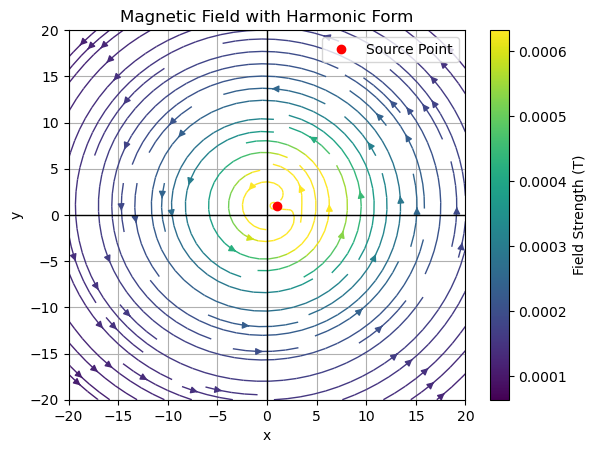

In [27]:
# B-field for the case of r>a:

# Need to define R
def B_harm(x, y, x_a, y_a, I):
    dx = x - x_a
    dy = y - y_a

    r = np.sqrt(dx**2 + dy**2)
    ang = np.arctan2(dy, dx)

    a = np.sqrt(x_a**2 + y_a**2)

    # Avoid division by zero
    r = np.where(r == 0, 1e-10, r)

    n_max = 10

    # Compute terms for both cases

    # Case for r > a:
    B_r_out = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(a / r)**(n + 1) * np.sin(n * ang) for n in range(0, n_max)], axis=0)
    B_theta_out = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(a / r)**(n + 1) * np.cos(n * ang) for n in range(0, n_max)], axis=0)

    # Case for r < a:
    B_r_in = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(r / a)**(n - 1) * np.sin(n * ang) for n in range(1, n_max)], axis=0)
    B_theta_in = -((mu0 * I) / (2 * np.pi * a)) * np.sum([(r / a)**(n - 1) * np.cos(n * ang) for n in range(1, n_max)], axis=0)

    # Use np.where to select the correct values
    # np.where(cond., x, y) -> # If true, takes x; if false, takes y
    B_r = np.where(r > a, B_r_out, B_r_in) 
    B_theta = np.where(r > a, B_theta_out, B_theta_in)

    # Convert to cartesian coordinates
    B_x = B_r * np.cos(ang) - B_theta * np.sin(ang)
    B_y = B_r * np.sin(ang) + B_theta * np.cos(ang)

    return B_x, B_y



# Grid setup
x = np.linspace(-20, 20, 1000)
y = np.linspace(-20, 20, 1000)
X, Y = np.meshgrid(x, y)

# Source point (x_a, y_a) and current I
x_a, y_a = 1, 1
I = 16000  # current

# Compute the field
Bx, By = B_harm(X, Y, x_a, y_a, I)
field_mag = np.sqrt(Bx**2 + By**2)

# Plotting
#plt.figure(figsize=(6, 6))
norm = mcolors.Normalize(vmin=field_mag.min(), vmax=np.percentile(field_mag, 95)) 
plt.streamplot(X, Y, Bx, By, color=field_mag, cmap='viridis', linewidth=1, zorder=2, norm=norm)
plt.plot(x_a, y_a, 'ro', label='Source Point')
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Magnetic Field with Harmonic Form')
plt.colorbar(label='Field Strength (T)')
plt.legend(loc="upper right")
#plt.axis('equal')
plt.grid(True)
plt.show()


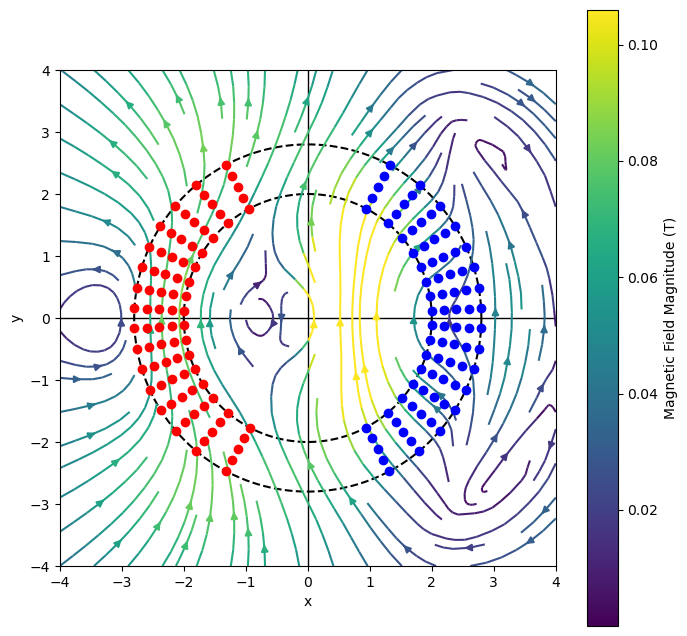

In [28]:
# Here, we define the B-field in terms of its harmonic components
def B_harm(x, y, x_a, y_a, I):
    dx = x - x_a
    dy = y - y_a

    r = np.sqrt(dx**2 + dy**2)
    ang = np.arctan2(dy, dx)

    a = np.sqrt(x_a**2 + y_a**2)

    # Avoid division by zero
    r = np.where(r == 0, 1e-10, r)

    # Max N value for the harmonic series
    n_max = 1

    # Compute terms for both cases

    # Case for r > a:
    B_r_out = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(a / r)**(n + 1) * np.sin(n * ang) for n in range(0, n_max+1)], axis=0)
    B_theta_out = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(a / r)**(n + 1) * np.cos(n * ang) for n in range(0, n_max+1)], axis=0)

    # Case for r < a:
    B_r_in = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(r / a)**(n - 1) * np.sin(n * ang) for n in range(1, n_max+1)], axis=0)
    B_theta_in = (-1)*((mu0 * I) / (2 * np.pi * a)) * np.sum([(r / a)**(n - 1) * np.cos(n * ang) for n in range(1, n_max+1)], axis=0)

    # Use np.where to select the correct values
    # np.where(cond., x, y) -> # If true, takes x; if false, takes y
    B_r = np.where(r > a, B_r_out, B_r_in) 
    B_theta = np.where(r > a, B_theta_out, B_theta_in)

    # Convert to cartesian coordinates
    B_x = B_r * np.cos(ang) - B_theta * np.sin(ang)
    B_y = B_r * np.sin(ang) + B_theta * np.cos(ang)

    return B_x, B_y
##################################################################################################

# Constants
mu0 = 4 * np.pi * 1e-7 # Vacuum permeability
radius = 2 # Radius from origin as starting point (inner layer)
# Outter radius is controlled by amount of condutors present in block
num_conductors = 32 # Total number of blocks (divide by 4 to get number of blocks per quadrant)
n_radial = 5 # Number of conductors per block
dr = 0.2 # Radial spacing of conductors
excluded_angles = [0, np.pi/2, np.pi, 3*np.pi/2] # Angles where we do not want points to lie on
I0 = 16000 # Current magnitude

# List of angles following a cosine theta distribution, symmetric about y axis
half_conductors = num_conductors // 2 # Total number of conductors per side

theta_half = np.linspace(-np.pi/2, np.pi/2, 1000) # Creates a linspace of the right side of the magnet (quadrants 1 and 4), 1000 is the number of values in the linspace
I_theta_half = np.cos(theta_half) # Calculates the current for each of these points in the right side


# pdf/cdf allows you to space things according to a desired density function
pdf_half = I_theta_half / np.sum(I_theta_half)  # Define a probability-like distribution representing how densely points should be spaced
cdf_half = np.cumsum(pdf_half)  # Convert this distribution into a cumulative sum (CDF), which lets us map uniform samples to angles weighted by this distribution
# Used for inverse transform sampling: mapping uniform samples to a desired distribution

# Creates a space of points in the interval (0,1), where the number of points is half the total conductors we have
# The line [1:-1] ensures we do not include 0 and 1
# Inverses the CDF to get the points
u = np.linspace(0, 1, half_conductors + 2)[1:-1]

# Interp takes: points, x values, y values
theta_right = np.interp(u, cdf_half, theta_half) # Right side of plot
theta_left = np.pi - theta_right # Reflection to left side of plot

theta_list = np.sort(np.concatenate([theta_right, theta_left]))


# Filter excluded angles from the list of where points can be plotted
epsilon = 1e-5
theta_filtered = np.array([
    angle for angle in theta_list
    if all(np.abs(angle - ex) > epsilon for ex in excluded_angles)
])

# Determines the position of the conductors from the given angles
r0 = radius # Inner radius

radii = [r0 + i * dr for i in range(n_radial)]

# Maps out the wires and how they should be distributed
wire_params = []
for theta in theta_filtered:
    for r in radii:
        x = r * np.cos(theta)
        y = r * np.sin(theta)

        # Determine current direction by quadrant
        if x > 0:
            current = (-1)*I0  # Q1 & Q4 (right side)
        elif x < 0:
            current = I0   # Q2 & Q3 (left side)
        else:
            current = 0  # Edge case — not expected
        wire_params.append((x, y, current))

# B-field components are computed

# We set them up as arrays with the same dimensions as X and Y

# Grid setup
x = np.linspace(-4, 4, 1000)
y = np.linspace(-4, 4, 1000)
X, Y = np.meshgrid(x, y)

Bx_total = np.zeros_like(X)
By_total = np.zeros_like(Y)

# Calculate field for each wire component
for x0, y0, I in wire_params:
    Bx, By = B_harm(X, Y, x0, y0, I)  # ← use your B_harm function here
    Bx_total += Bx
    By_total += By


# Total B-field magnitudes are computed
B_mag = np.sqrt(Bx_total**2 + By_total**2)

####################################################################################
# Plotting

plt.figure(figsize=(8, 8))

# Stream plot of magnetic field
# Only shows 95th percentile as max to make line magnitudes easier to see
norm = mcolors.Normalize(vmin=B_mag.min(), vmax=np.percentile(B_mag, 95)) 
strm = plt.streamplot(X, Y, Bx_total, By_total, color=B_mag, cmap='viridis', norm=norm)
cbar = plt.colorbar(strm.lines, label='Magnetic Field Magnitude (T)')

# Plot conductors
for x0, y0, I in wire_params:
    color = 'r' if I > 0 else 'b'
    plt.plot(x0, y0, 'o', color=color)

# Draw inner circle (optional reference)
theta_circle = np.linspace(0, 2*np.pi, 500)
x_circle = radius * np.cos(theta_circle)
y_circle = radius * np.sin(theta_circle)
plt.plot(x_circle, y_circle, 'k--', zorder=0)

# Draw outer circle to contain all conductors (defined by number of conductors)
outer_radius = r0 + (n_radial - 1) * dr
theta_circle = np.linspace(0, 2 * np.pi, 500)
x_outer = outer_radius * np.cos(theta_circle)
y_outer = outer_radius * np.sin(theta_circle)
plt.plot(x_outer, y_outer, 'k--', zorder=0)

# Axes & final layout
plt.axhline(0, color='black', linewidth=1, zorder=0)
plt.axvline(0, color='black', linewidth=1, zorder=0)
plt.gca().set_aspect('equal')
plt.xlabel("x")
plt.ylabel("y")
#plt.title("")
plt.show()


In [29]:
# Here we are investigating the harmonic series for the case of r > a:
I=10
a=5
r=20
ang=(np.pi)/(6)
r_sum_terms = [(a/r)**(n+1)*np.sin(n*ang) for n in range(1,10)]
print(r_sum_terms)
print("")

# This shows why we use 10^4 as a unit for the harmonics
# We can see how quick the harmonics fall
for index, term in enumerate(r_sum_terms):
    print(str(index+1) + ": " + str(((mu0 * I) / (2 * np.pi * a)) * term * (10**4)))

[0.031249999999999997, 0.013531646934131853, 0.00390625, 0.0008457279333832409, 0.00012207031250000008, 7.474650873702107e-21, -7.629394531249996e-06, -3.303624739778284e-06, -9.5367431640625e-07]

1: 0.000125
2: 5.412658773652741e-05
3: 1.5625e-05
4: 3.382911733532964e-06
5: 4.882812500000003e-07
6: 2.989860349480843e-23
7: -3.051757812499999e-08
8: -1.3214498959113138e-08
9: -3.814697265625e-09


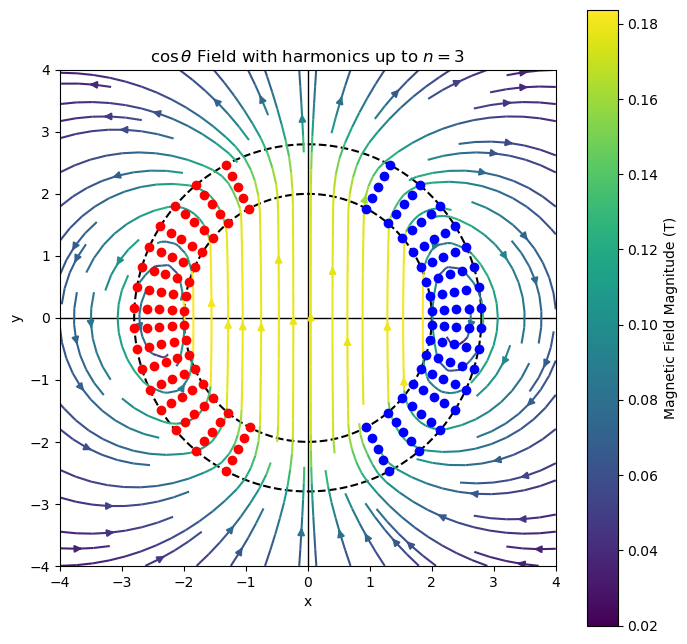

In [32]:
# Here, we define the B-field in terms of its harmonic components
# Max N value for the harmonic series
n_max = 3

def B_harm(x, y, x_a, y_a, I):
    r = np.sqrt(x**2 + y**2)
    a = np.sqrt(x_a**2 + y_a**2)

    phi = np.arctan2(y_a, x_a)
    theta = np.arctan2(y, x)

    ang = phi - theta

    # Avoid division by zero
    r = np.where(r == 0, 1e-10, r)

    # Compute terms for both cases

    # Case for r > a:
    B_r_out = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(a / r)**(n + 1) * np.sin(n * ang) for n in range(0, n_max+1)], axis=0)
    B_theta_out = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(a / r)**(n + 1) * np.cos(n * ang) for n in range(0, n_max+1)], axis=0)

    # Case for r < a:
    B_r_in = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(r / a)**(n - 1) * np.sin(n * ang) for n in range(1, n_max+1)], axis=0)
    B_theta_in = (-1)*((mu0 * I) / (2 * np.pi * a)) * np.sum([(r / a)**(n - 1) * np.cos(n * ang) for n in range(1, n_max+1)], axis=0)

    # Use np.where to select the correct values
    # np.where(cond., x, y) -> # If true, takes x; if false, takes y
    
    B_r = np.where(r > a, B_r_out, B_r_in) 
    B_theta = np.where(r > a, B_theta_out, B_theta_in)

    # Convert to cartesian coordinates
    B_x = B_r * np.cos(theta) - B_theta * np.sin(theta)
    B_y = B_r * np.sin(theta) + B_theta * np.cos(theta)

    return B_x, B_y

##################################################################################################

# Constants
mu0 = 4 * np.pi * 1e-7 # Vacuum permeability
radius = 2 # Radius from origin as starting point (inner layer)
# Outter radius is controlled by amount of condutors present in block
num_conductors = 32 # Total number of blocks (divide by 4 to get number of blocks per quadrant)
n_radial = 5 # Number of conductors per block
dr = 0.2 # Radial spacing of conductors
excluded_angles = [0, np.pi/2, np.pi, 3*np.pi/2] # Angles where we do not want points to lie on
I0 = 16000 # Current magnitude

# List of angles following a cosine theta distribution, symmetric about y axis
half_conductors = num_conductors // 2 # Total number of conductors per side

theta_half = np.linspace(-np.pi/2, np.pi/2, 1000) # Creates a linspace of the right side of the magnet (quadrants 1 and 4), 1000 is the number of values in the linspace
I_theta_half = np.cos(theta_half) # Calculates the current for each of these points in the right side


# pdf/cdf allows you to space things according to a desired density function
pdf_half = I_theta_half / np.sum(I_theta_half)  # Define a probability-like distribution representing how densely points should be spaced
cdf_half = np.cumsum(pdf_half)  # Convert this distribution into a cumulative sum (CDF), which lets us map uniform samples to angles weighted by this distribution
# Used for inverse transform sampling: mapping uniform samples to a desired distribution

# Creates a space of points in the interval (0,1), where the number of points is half the total conductors we have
# The line [1:-1] ensures we do not include 0 and 1
# Inverses the CDF to get the points
u = np.linspace(0, 1, half_conductors + 2)[1:-1]

# Interp takes: points, x values, y values
theta_right = np.interp(u, cdf_half, theta_half) # Right side of plot
theta_left = np.pi - theta_right # Reflection to left side of plot

theta_list = np.sort(np.concatenate([theta_right, theta_left]))


# Filter excluded angles from the list of where points can be plotted
epsilon = 1e-5
theta_filtered = np.array([
    angle for angle in theta_list
    if all(np.abs(angle - ex) > epsilon for ex in excluded_angles)
])

# Determines the position of the conductors from the given angles
r0 = radius # Inner radius

radii = [r0 + i * dr for i in range(n_radial)]

# Maps out the wires and how they should be distributed
wire_params = []
for theta in theta_filtered:
    for r in radii:
        x = r * np.cos(theta)
        y = r * np.sin(theta)

        # Determine current direction by quadrant
        if x > 0:
            current = (-1)*I0  # Q1 & Q4 (right side)
        elif x < 0:
            current = I0   # Q2 & Q3 (left side)
        else:
            current = 0  # Edge case — not expected
        wire_params.append((x, y, current))

# B-field components are computed

# We set them up as arrays with the same dimensions as X and Y

# Grid setup
x = np.linspace(-4, 4, 1000)
y = np.linspace(-4, 4, 1000)
X, Y = np.meshgrid(x, y)

Bx_total = np.zeros_like(X)
By_total = np.zeros_like(Y)

# Calculate field for each wire component
for x0, y0, I in wire_params:
    Bx, By = B_harm(X, Y, x0, y0, I)  # ← use your B_harm function here
    Bx_total += Bx
    By_total += By


# Total B-field magnitudes are computed
B_mag = np.sqrt(Bx_total**2 + By_total**2)

####################################################################################
# Plotting

plt.figure(figsize=(8, 8))

# Stream plot of magnetic field
# Only shows 95th percentile as max to make line magnitudes easier to see
#norm = mcolors.Normalize(vmin=B_mag.min(), vmax=np.percentile(B_mag, 95)) 
strm = plt.streamplot(X, Y, Bx_total, By_total, color=B_mag, cmap='viridis')
cbar = plt.colorbar(strm.lines, label='Magnetic Field Magnitude (T)')

# Plot conductors
for x0, y0, I in wire_params:
    color = 'r' if I > 0 else 'b'
    plt.plot(x0, y0, 'o', color=color)

# Draw inner circle (optional reference)
theta_circle = np.linspace(0, 2*np.pi, 500)
x_circle = radius * np.cos(theta_circle)
y_circle = radius * np.sin(theta_circle)
plt.plot(x_circle, y_circle, 'k--', zorder=0)

# Draw outer circle to contain all conductors (defined by number of conductors)
outer_radius = r0 + (n_radial - 1) * dr
theta_circle = np.linspace(0, 2 * np.pi, 500)
x_outer = outer_radius * np.cos(theta_circle)
y_outer = outer_radius * np.sin(theta_circle)
plt.plot(x_outer, y_outer, 'k--', zorder=0)

# Axes & final layout
plt.axhline(0, color='black', linewidth=1, zorder=0)
plt.axvline(0, color='black', linewidth=1, zorder=0)
plt.gca().set_aspect('equal')
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"$\\cos \\theta$ Field with harmonics up to $n=${n_max}")
plt.show()
